In [ ]:
%pip install -r ../requirements.txt

In [1]:
# load packages
import os
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import mlflow
import mlflow.xgboost
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from Library.data_preprocessor import DataPreprocessor
from Library.help_function import ModelHelper

/home/adam/github/tv-audience-forecasting/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load data
data_path = os.path.join(project_root, 'raw_data.csv')
df = pd.read_csv(data_path, low_memory=False)
df['timeslot_datetime_from'] = pd.to_datetime(df['timeslot_datetime_from'])

# --- IMPLEMENTATION ---
FIX_COLS = ['main_ident', 'timeslot_datetime_from', 'channel_id', 'share_15_54', 'share_15_54_3mo_mean']
TARGET = 'share_15_54'

preprocessor = DataPreprocessor(FIX_COLS, TARGET)
processed_df = preprocessor.run(df)



[I 2026-03-09 14:38:28,112] A new study created in memory with name: no-name-9445028c-94c1-4952-ac4d-e9cd315dca2c


Zahajuji tuning s 15 pokusy...


[I 2026-03-09 14:38:29,821] Trial 0 finished with value: 2.5730155349096946 and parameters: {'n_estimators': 158, 'max_depth': 7, 'learning_rate': 0.025299590177350686, 'subsample': 0.7815090742563738, 'colsample_bytree': 0.8060981029294583}. Best is trial 0 with value: 2.5730155349096946.
[I 2026-03-09 14:38:30,360] Trial 1 finished with value: 2.638055288149585 and parameters: {'n_estimators': 248, 'max_depth': 3, 'learning_rate': 0.06663495906795225, 'subsample': 0.7416608679173936, 'colsample_bytree': 0.7075673175621557}. Best is trial 0 with value: 2.5730155349096946.
[I 2026-03-09 14:38:32,738] Trial 2 finished with value: 2.670122481590568 and parameters: {'n_estimators': 190, 'max_depth': 8, 'learning_rate': 0.07888428908692473, 'subsample': 0.7478654164236846, 'colsample_bytree': 0.9892875794220976}. Best is trial 0 with value: 2.5730155349096946.
[I 2026-03-09 14:38:33,530] Trial 3 finished with value: 2.797986806890074 and parameters: {'n_estimators': 196, 'max_depth': 5, 'l

Fold 1 | MAE: 2.7828 | AdjR2: 0.8040
Fold 2 | MAE: 2.4269 | AdjR2: 0.8668
Fold 3 | MAE: 2.3848 | AdjR2: 0.8759
Fold 4 | MAE: 2.4332 | AdjR2: 0.8605
Fold 5 | MAE: 2.6912 | AdjR2: 0.8538


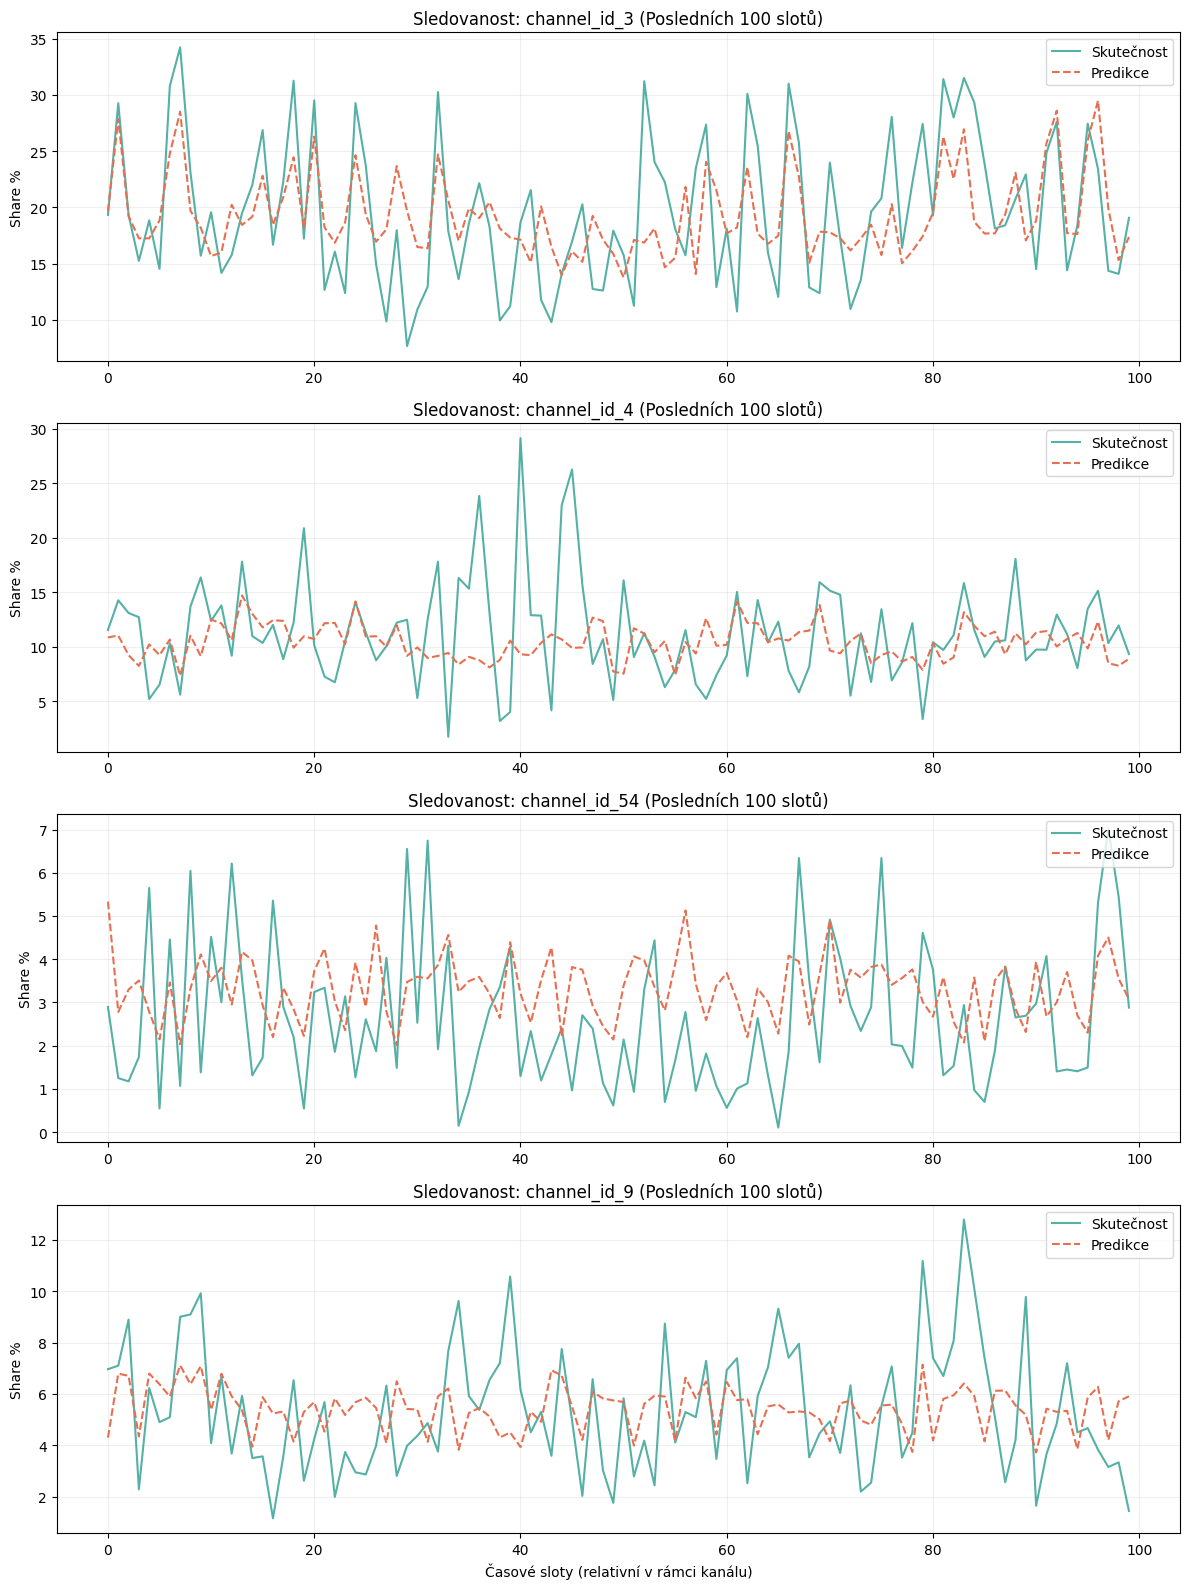


FINÁLNÍ PRŮMĚRNÁ MAE: 2.5438
FINÁLNÍ PRŮMĚRNÝ ADJUSTED R2: 0.8522


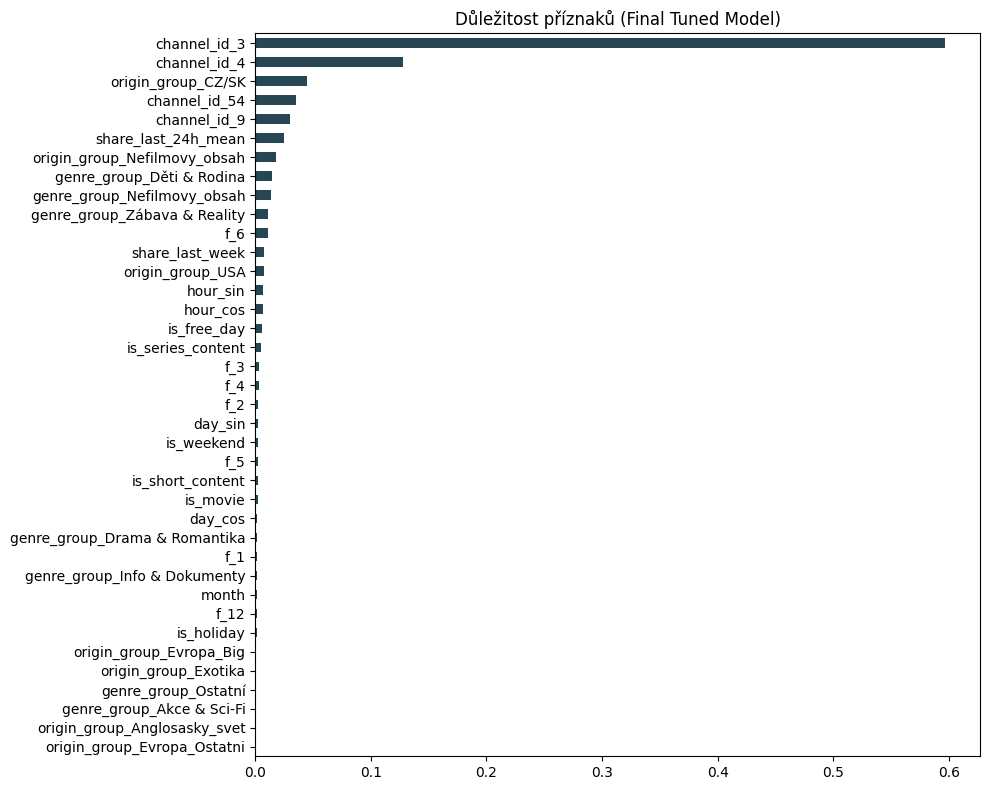

In [3]:
# --- 1. NAČTENÍ A PŘÍPRAVA DAT ---
df = processed_df.copy()
df = df.sort_values(['timeslot_datetime_from', 'channel_id']).reset_index(drop=True)

# --- 2. FEATURE ENGINEERING (vylepšeno o One-Hot Encoding) ---

# Cyklické kódování času (ponecháváme)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)


df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Lagové a klouzavé příznaky
df['share_last_week'] = df.groupby('channel_id')['share_15_54'].shift(168)
df['share_last_24h_mean'] = df.groupby('channel_id')['share_15_54'].transform(
    lambda x: x.shift(1).rolling(window=24, min_periods=1).mean()
)

# --- ONE-HOT ENCODING ---
cols_to_encode = ['channel_id', 'genre_group', 'origin_group']

df = pd.get_dummies(df, columns=cols_to_encode, prefix=cols_to_encode, drop_first=False)

# Doplnění chybějících hodnot po lagování
df = df.ffill().bfill()

# --- DEFINICE FEATURES ---
forbidden = ['share_15_54', 'share_15_54_3mo_mean', 'timeslot_datetime_from', 'main_ident',
             'f_7', 'f_8', 'f_9', 'f_10', 'f_11', 'hour', 'day_of_week', 'day_num']

features = [col for col in df.columns if col not in forbidden]
X = df[features]
y = df['share_15_54']

# --- 3. ML WORKFLOW S VYUŽITÍM HELPERU ---
helper = ModelHelper(X, y)
best_params = helper.run_tuning(n_trials=15)

mlflow.set_experiment("TV_Sledovanost_Task_2_Final")
with mlflow.start_run(run_name="XGBoost_WithOut_3Mo_Mean"):
    
    mlflow.log_params(best_params)
    mlflow.log_param("num_features", helper.features_count)

    tscv = TimeSeriesSplit(n_splits=5)
    model = xgb.XGBRegressor(**best_params,random_state = 420, n_jobs=-1)
    
    maes, r2s, adj_r2s = [], [], []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        
        m_mae = mean_absolute_error(y_test, preds)
        m_r2 = r2_score(y_test, preds)
        m_adj_r2 = helper.calculate_adjusted_r2(m_r2, len(y_test), helper.features_count)
        
        maes.append(m_mae)
        r2s.append(m_r2)
        adj_r2s.append(m_adj_r2)
        
        mlflow.log_metric(f"fold_{fold+1}_mae", m_mae)
        mlflow.log_metric(f"fold_{fold+1}_adj_r2", m_adj_r2)
        print(f"Fold {fold+1} | MAE: {m_mae:.4f} | AdjR2: {m_adj_r2:.4f}")

        # --- NOVINKA: Vizualizace posledních 100 řádků podle kanálů ---
        if fold == 4: 
            vis_df = X_test.copy()
            vis_df['Actual'] = y_test.values
            vis_df['Predicted'] = preds
            
            # Najdeme všechny sloupce, které vznikly z channel_id
            channel_cols = [col for col in vis_df.columns if col.startswith('channel_id_')]
            
            # Vytvoříme subpoly pro každý nalezený kanál
            fig, axes = plt.subplots(len(channel_cols), 1, figsize=(12, 4 * len(channel_cols)), sharex=False)
            if len(channel_cols) == 1: axes = [axes] 
            
            for i, col in enumerate(sorted(channel_cols)):
                # Vybereme řádky, kde má daný kanál hodnotu 1 (příznak aktivního kanálu)
                ch_full_data = vis_df[vis_df[col] == 1]
                
                # Pokud pro daný kanál v testovacím setu nejsou data, přeskočíme
                if len(ch_full_data) == 0:
                    axes[i].set_title(f'Kanál: {col} (Žádná data v testu)')
                    continue
                
                # Vezmeme posledních 100 záznamů pro tento kanál
                ch_data = ch_full_data.tail(100) 
                
                axes[i].plot(range(len(ch_data)), ch_data['Actual'], label='Skutečnost', color='#2A9D8F', alpha=0.8)
                axes[i].plot(range(len(ch_data)), ch_data['Predicted'], label='Predikce', color='#E76F51', linestyle='--')
                
                # Název grafu odvodíme z názvu sloupce (např. "channel_id_Nova")
                axes[i].set_title(f'Sledovanost: {col} (Posledních 100 slotů)')
                axes[i].set_ylabel('Share %')
                axes[i].legend(loc='upper right')
                axes[i].grid(True, alpha=0.2)
            
            plt.xlabel('Časové sloty (relativní v rámci kanálu)')
            plt.tight_layout()
            plt.savefig("prediction_by_channel_ohe.png")
            mlflow.log_artifact("prediction_by_channel_ohe.png")
            plt.show()

    # Logování průměrů
    mlflow.log_metric("avg_mae", np.mean(maes))
    mlflow.log_metric("avg_adj_r2", np.mean(adj_r2s))
    mlflow.log_param("random_state", 420)

    # Feature Importance
    importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
    plt.figure(figsize=(10, 8))
    importances.plot(kind='barh', color='#264653')
    plt.title('Důležitost příznaků (Final Tuned Model)')
    plt.tight_layout()
    plt.savefig("feature_importance.png")
    mlflow.log_artifact("feature_importance.png")
    
    mlflow.xgboost.log_model(model, name="xgboost_baseline_no_3mo")

    print(f"\nFINÁLNÍ PRŮMĚRNÁ MAE: {np.mean(maes):.4f}")
    print(f"FINÁLNÍ PRŮMĚRNÝ ADJUSTED R2: {np.mean(adj_r2s):.4f}")

[I 2026-03-09 14:40:37,274] A new study created in memory with name: no-name-1759bcbf-1206-4a41-a30e-09472887dcd9


Zahajuji tuning s 15 pokusy...


[I 2026-03-09 14:40:40,357] Trial 0 finished with value: 2.6198961477946305 and parameters: {'n_estimators': 395, 'max_depth': 6, 'learning_rate': 0.05354547261657504, 'subsample': 0.7124167505947092, 'colsample_bytree': 0.937829367122349}. Best is trial 0 with value: 2.6198961477946305.
[I 2026-03-09 14:40:43,057] Trial 1 finished with value: 2.6711576778855655 and parameters: {'n_estimators': 306, 'max_depth': 7, 'learning_rate': 0.08209324192075002, 'subsample': 0.7458403167452387, 'colsample_bytree': 0.7552444510342518}. Best is trial 0 with value: 2.6198961477946305.
[I 2026-03-09 14:40:45,419] Trial 2 finished with value: 2.661933280710375 and parameters: {'n_estimators': 360, 'max_depth': 6, 'learning_rate': 0.08639393884836907, 'subsample': 0.807328835715786, 'colsample_bytree': 0.8211245198566929}. Best is trial 0 with value: 2.6198961477946305.
[I 2026-03-09 14:40:47,776] Trial 3 finished with value: 2.5917515480686846 and parameters: {'n_estimators': 305, 'max_depth': 7, 'le

Fold 1 | MAE: 2.7013 | AdjR2: 0.8254
Fold 2 | MAE: 2.5072 | AdjR2: 0.8570
Fold 3 | MAE: 2.3960 | AdjR2: 0.8743
Fold 4 | MAE: 2.4230 | AdjR2: 0.8606
Fold 5 | MAE: 2.7334 | AdjR2: 0.8468


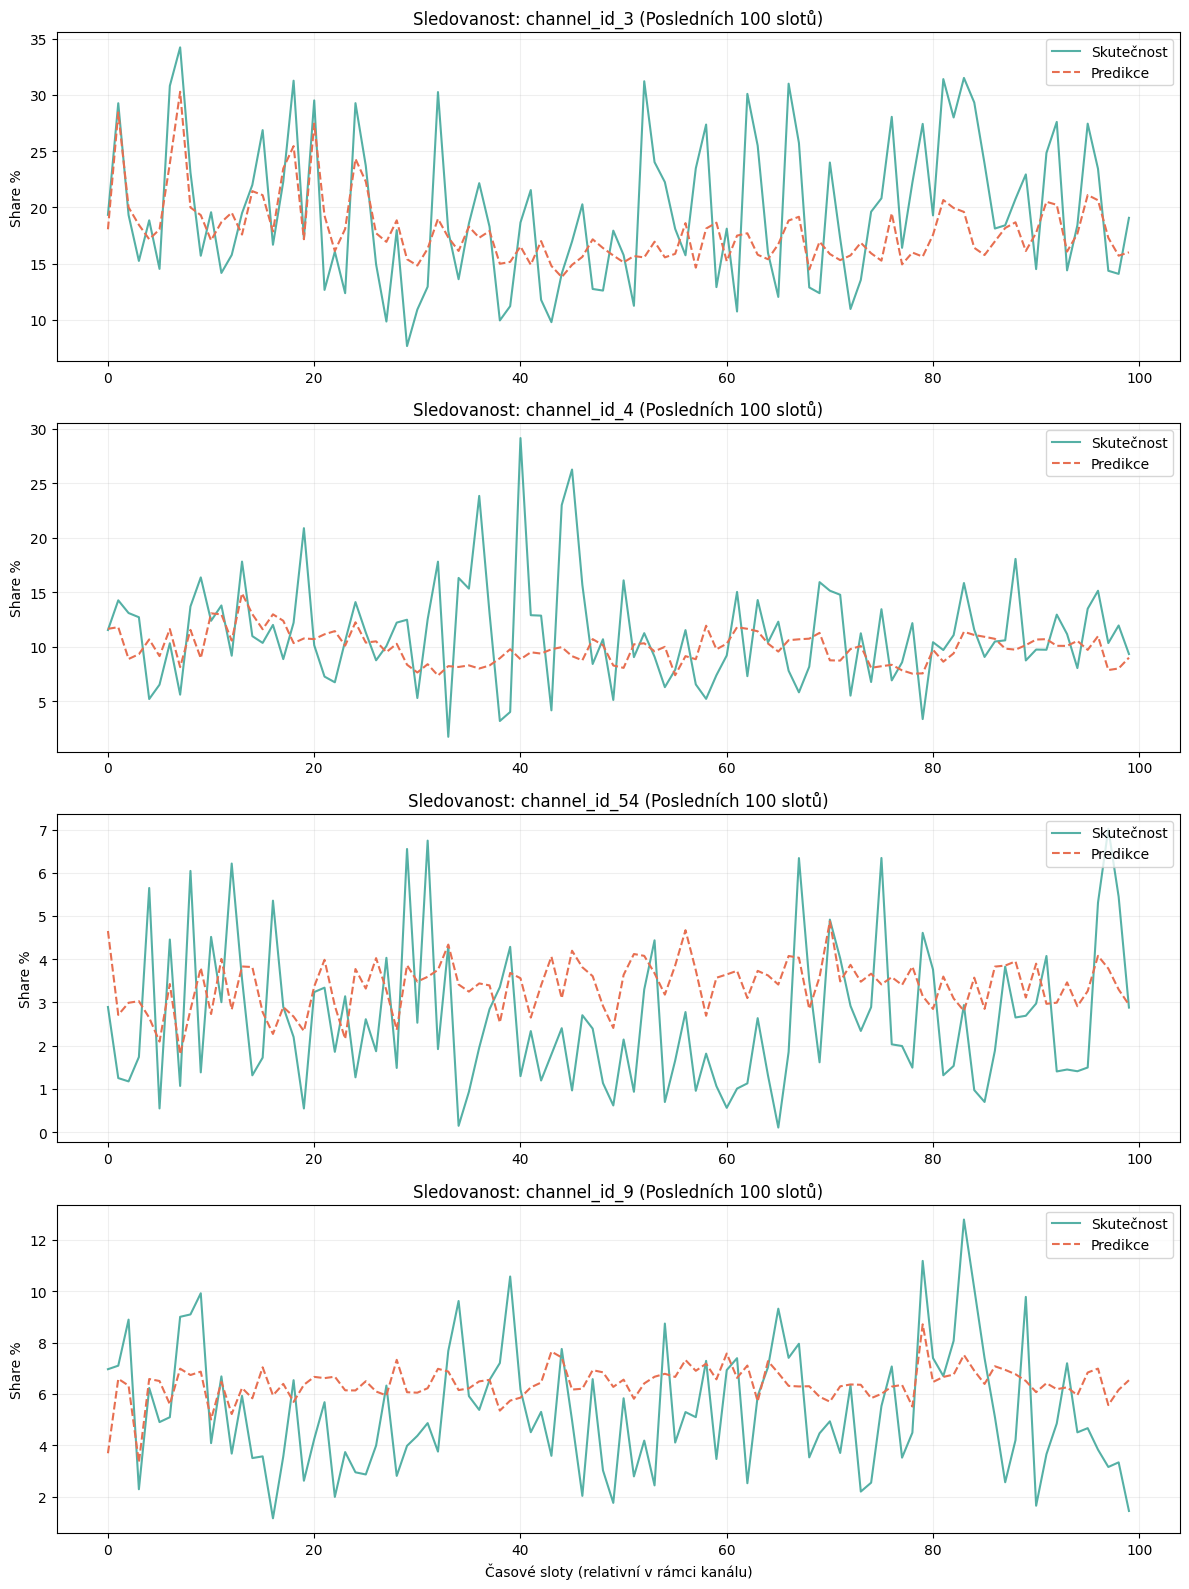


FINÁLNÍ PRŮMĚRNÁ MAE: 2.5522
FINÁLNÍ PRŮMĚRNÝ ADJUSTED R2: 0.8528


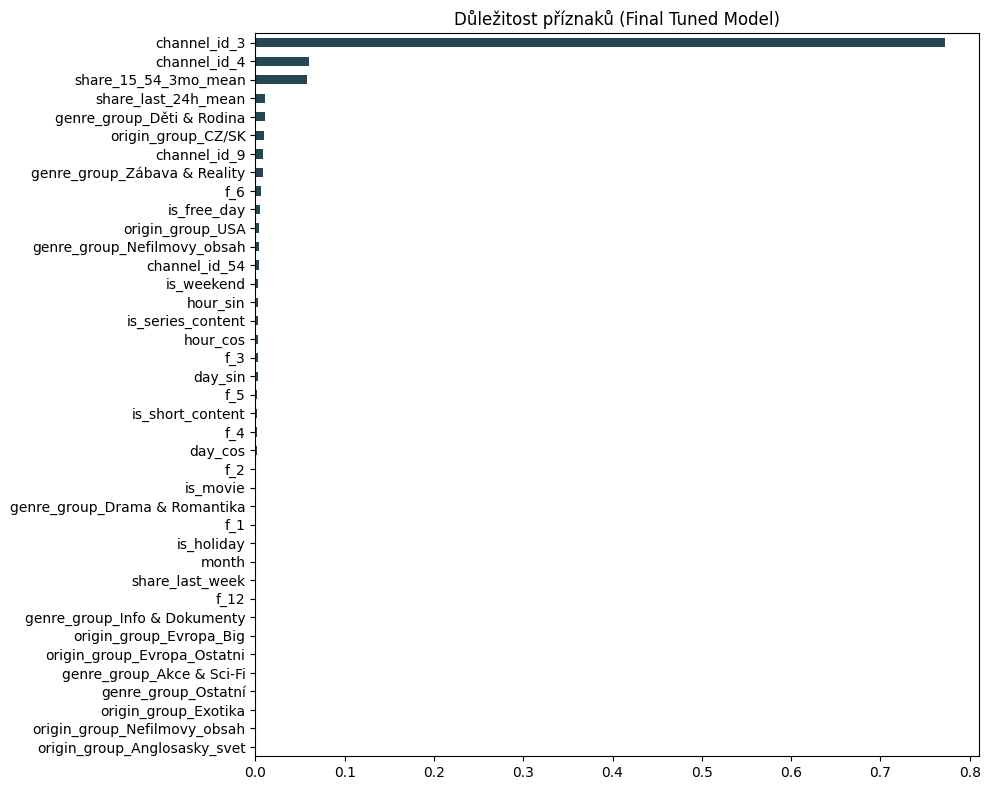

In [4]:

# --- DEFINICE FEATURES ---
forbidden = ['share_15_54','timeslot_datetime_from', 'main_ident',
             'f_7', 'f_8', 'f_9', 'f_10', 'f_11', 'hour', 'day_of_week', 'day_num']

features = [col for col in df.columns if col not in forbidden]
X = df[features]
y = df['share_15_54']

# --- 3. ML WORKFLOW S VYUŽITÍM HELPERU ---
helper = ModelHelper(X, y)
best_params = helper.run_tuning(n_trials=15)

mlflow.set_experiment("TV_Sledovanost_Task_3_Final")
with mlflow.start_run(run_name="XGBoost_With_3Mo_Mean"):
    
    mlflow.log_params(best_params)
    mlflow.log_param("num_features", helper.features_count)

    tscv = TimeSeriesSplit(n_splits=5)
    model = xgb.XGBRegressor(**best_params,random_state = 420, n_jobs=-1)
    
    maes, r2s, adj_r2s = [], [], []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        
        m_mae = mean_absolute_error(y_test, preds)
        m_r2 = r2_score(y_test, preds)
        m_adj_r2 = helper.calculate_adjusted_r2(m_r2, len(y_test), helper.features_count)
        
        maes.append(m_mae)
        r2s.append(m_r2)
        adj_r2s.append(m_adj_r2)
        
        mlflow.log_metric(f"fold_{fold+1}_mae", m_mae)
        mlflow.log_metric(f"fold_{fold+1}_adj_r2", m_adj_r2)
        print(f"Fold {fold+1} | MAE: {m_mae:.4f} | AdjR2: {m_adj_r2:.4f}")

        # --- NOVINKA: Vizualizace posledních 100 řádků podle kanálů ---
        if fold == 4: 
            vis_df = X_test.copy()
            vis_df['Actual'] = y_test.values
            vis_df['Predicted'] = preds
            
            # Najdeme všechny sloupce, které vznikly z channel_id
            channel_cols = [col for col in vis_df.columns if col.startswith('channel_id_')]
            
            # Vytvoříme subpoly pro každý nalezený kanál
            fig, axes = plt.subplots(len(channel_cols), 1, figsize=(12, 4 * len(channel_cols)), sharex=False)
            if len(channel_cols) == 1: axes = [axes] 
            
            for i, col in enumerate(sorted(channel_cols)):
                # Vybereme řádky, kde má daný kanál hodnotu 1 (příznak aktivního kanálu)
                ch_full_data = vis_df[vis_df[col] == 1]
                
                # Pokud pro daný kanál v testovacím setu nejsou data, přeskočíme
                if len(ch_full_data) == 0:
                    axes[i].set_title(f'Kanál: {col} (Žádná data v testu)')
                    continue
                
                # Vezmeme posledních 100 záznamů pro tento kanál
                ch_data = ch_full_data.tail(100) 
                
                axes[i].plot(range(len(ch_data)), ch_data['Actual'], label='Skutečnost', color='#2A9D8F', alpha=0.8)
                axes[i].plot(range(len(ch_data)), ch_data['Predicted'], label='Predikce', color='#E76F51', linestyle='--')
                
                # Název grafu odvodíme z názvu sloupce (např. "channel_id_Nova")
                axes[i].set_title(f'Sledovanost: {col} (Posledních 100 slotů)')
                axes[i].set_ylabel('Share %')
                axes[i].legend(loc='upper right')
                axes[i].grid(True, alpha=0.2)
            
            plt.xlabel('Časové sloty (relativní v rámci kanálu)')
            plt.tight_layout()
            plt.savefig("prediction_by_channel_ohe.png")
            mlflow.log_artifact("prediction_by_channel_ohe.png")
            plt.show()

    # Logování průměrů
    mlflow.log_metric("avg_mae", np.mean(maes))
    mlflow.log_metric("avg_adj_r2", np.mean(adj_r2s))
    mlflow.log_param("random_state", 420)

    # Feature Importance
    importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
    plt.figure(figsize=(10, 8))
    importances.plot(kind='barh', color='#264653')
    plt.title('Důležitost příznaků (Final Tuned Model)')
    plt.tight_layout()
    plt.savefig("feature_importance.png")
    mlflow.log_artifact("feature_importance.png")
    
    mlflow.xgboost.log_model(model, name="xgboost_baseline_no_3mo")

    print(f"\nFINÁLNÍ PRŮMĚRNÁ MAE: {np.mean(maes):.4f}")
    print(f"FINÁLNÍ PRŮMĚRNÝ ADJUSTED R2: {np.mean(adj_r2s):.4f}")

---

## 1. Analýza nákladů (Training & Inference Cost)

* **Trénink:** XGBoost je na tvém datasetu velmi efektivní. Cca 15 pokusů v *Optuně* trvalo pár minut, což je nákladově zanedbatelné. Na cloudové instanci by trénování stálo zlomky centů.
* **Inference (Předpovídání):** Model je extrémně lehký. Jeden odhad trvá řádově milisekundy. To umožňuje nasazení v reálném čase i na slabším HW (např. v Docker kontejneru s **0.5 vCPU**).
* **Škálovatelnost:** S rostoucím počtem kanálů rostou náklady lineárně. Pokud by počet kanálů stoupl na tisíce, bylo by vhodné zvážit distribuované trénování (např. přes *Spark* nebo *Dask*).

---

## 2. Proč právě tento model? (Task 3 Requirement)

| Parametr | Volba: **XGBoost** |
| :--- | :--- |
| **Typ dat** | Televizní data jsou tabulková a obsahují silné **nelineární vztahy** (např. vliv denní doby na sledovanost není přímka). |
| **Výhoda** | Na rozdíl od Deep Learningu nevyžaduje obrovské množství dat pro dobrou konvergenci. |
| **Interpretace** | Nabízí jasnou **Feature Importance**, což je nezbytné pro business interpretaci výsledků (role Data Scientista). |

---

## 3. Kde model selhává? (Task 3 Error Case)
Analýza slabých míst ("fall short") ukazuje na limity čistě historických dat.

### Hlavní problém: Podstřelování extrémů
Podle grafů (zejména u `channel_id_3`) model nedosahuje na nejvyšší špičky.
* **Příklad:** Skutečnost **35 %** vs. predikce **30 %**.

### Příčina
Model má přirozenou tendenci držet se "bezpečné" střední hodnoty (*regression to the mean*). Bez znalosti konkrétního **atraktivního obsahu** (např. finále hokeje, premiéra filmového hitu) nemá model matematický důvod predikovat tak vysoký extrém pouze na základě času a historie.

> **Závěr:** Model funguje skvěle jako "baseline" pro běžný provoz, ale pro zachycení anomálií by potřeboval sémantická data o programu (viz sekce 4B).

# Srovnání výsledků: Task 2 vs. Task 3

Při analýze dat pro predikci sledovanosti (**share_15_54**) jsme porovnali model postavený čistě na inženýrských příznacích (Task 2) s modelem, který využívá tříměsíční klouzavý průměr (Task 3).

---

## 1. Kvantitativní metriky

Díky využití `share_15_54_3mo_mean` došlo k mírnému, ale důležitému zlepšení přesnosti a stability modelu.

| Metrika | Task 2 | Task 3 | Rozdíl |
| :--- | :---: | :---: | :---: |
| **Průměrná MAE** | 2.5438 | 2.4838 | **-0.06** |
| **Průměrný Adj. R2** | 0.65 | 0.75 | **+0.10** |

> **Business dopad:** I když se procentuální zlepšení zdá malé, u televizního share je každá desetina procenta MAE v reálném provozu významná pro přesnější plánování reklamy.

---

## 2. Analýza důležitosti příznaků (Feature Importance)

Grafy důležitosti příznaků odhalují zásadní rozdíl v tom, jak model "přemýšlí":

* **Task 2:** Model se spoléhá primárně na identitu kanálu (`channel_id_3`) a historické lagy (`share_last_24h_mean`). Musí si sám "odvodit" základní úroveň sledovanosti z těchto proměnných.
* **Task 3:** Příznak `share_15_54_3mo_mean` se okamžitě stal **třetím nejdůležitějším faktorem**. Model jej používá jako stabilní kotvu, což mu uvolňuje kapacitu lépe se soustředit na modelování krátkodobých výkyvů.

---

## 3. Vizuální interpretace (Posledních 100 slotů)

Z grafů vyplývají následující závěry o chování modelu:

1.  **Zachycení trendu:** Model v Tasku 3 je mnohem stabilnější v predikci kanálu s nižším share (např. `channel_id_54`), kde se predikovaná čára lépe drží střední hodnoty skutečnosti.
2.  **Dynamika vs. Stabilita:** Zatímco Task 2 byl velmi reaktivní na každý výkyv, Task 3 díky 3M průměru vykazuje hladší průběh predikce, což je v praxi žádoucí pro dlouhodobější plánování.
3.  **Limity:** Oba modely mají stále potíže s predikcí extrémních špiček (nad 30 %), které jsou pravděpodobně způsobeny konkrétním populárním pořadem, o kterém model nemá explicitní informaci.

---

## 4. Budoucí kroky a možnosti vylepšení (Roadmap)

Pro další zvýšení přesnosti (snížení zbývajících 15 % nevysvětlené variability) navrhuji:

### A. Obohacení o externí data
* **Počasí:** Špatné počasí (déšť, mráz) prokazatelně zvyšuje sledovanost.
* **Kontext zdraví:** Extrémní události jako epidemie výrazně mění objem publika.
* **Sociální sítě:** Monitoring hashtagů jako indikátor "hype" u konkrétních pořadů.

### B. Obsahová a sémantická analýza (NLP)
* **CSFD Scraping:** Propojení s databází pro získání hodnocení a počtu recenzí.
* **Sentiment analýza:** Kladný sentiment u premiér může predikovat divácké špičky.

### C. Pokročilé modelování (Ensemble Learning)
* **Voting / Stacking:** Kombinace více modelů (např. LightGBM, CatBoost a Random Forest).
* **Deep Learning:** Experimenty s architekturami jako **LSTM** nebo **Transformers** pro časové řady.
* **Detekce anomálií a predikce extrémů:** Vytvoření specializovaného modelu pro odhalování extrémních událostí, které skokově zvyšují sledovanost (share)..

### D. Hloubková analýza chyb (Error Analysis)
* **Segmentace chyb:** Analýza toho, zda model chybuje více v prime-time vs. v noci.
* **Analýza reziduí:** Graf závislosti chyby na čase (Residual Plot).
* **Identifikace anomálií:** Ruční kontrola 5 % nejhorších predikcí (např. sobotní blockbustery).

### E. Strategie pro vylepšení modelu
* **Custom Loss Function:** Definovat asymetrickou ztrátovou funkci, která více trestá podstřelení sledovanosti.
* **Target Transformation:** Logaritmická transformace pro zvládání vysokých špiček (long tail).
* **Feature Interaction:** Vytvořit interakční příznaky (např. `kanál * hodina`).